# Лабораторная работа №1

Работа с данными:

In [332]:
import kagglehub
import pandas as pd
import numpy as np

path = kagglehub.dataset_download("aldinwhyudii/student-depression-and-lifestyle-100k-data")
df = pd.read_csv(f"{path}/student_lifestyle_100k.csv")

Using Colab cache for faster access to the 'student-depression-and-lifestyle-100k-data' dataset.


In [333]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  object 
 3   Department          100000 non-null  object 
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), object(2)
memory usage: 7.7+ MB


In [334]:
print("\nFirst 5 students:")
df.head()


First 5 students:


,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


In [335]:
print(f"\nПропущенные значения:\n{df.isnull().sum()}")
print(f"\nДубликаты: {df.duplicated().sum()}")
df.drop_duplicates()


Пропущенные значения:
Student_ID            0
Age                   0
Gender                0
Department            0
CGPA                  0
Sleep_Duration        0
Study_Hours           0
Social_Media_Hours    0
Physical_Activity     0
Stress_Level          0
Depression            0
dtype: int64

Дубликаты: 0


,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False
...,...,...,...,...,...,...,...,...,...,...,...
99995,100996,24,Female,Medical,2.02,7.0,0.6,1.4,66,4,False
99996,100997,24,Male,Arts,2.33,5.0,3.6,5.2,103,3,False
99997,100998,24,Female,Engineering,2.23,6.5,5.8,4.1,61,5,False
99998,100999,19,Male,Engineering,3.61,6.1,4.8,4.9,116,4,False


Визуальное представление:

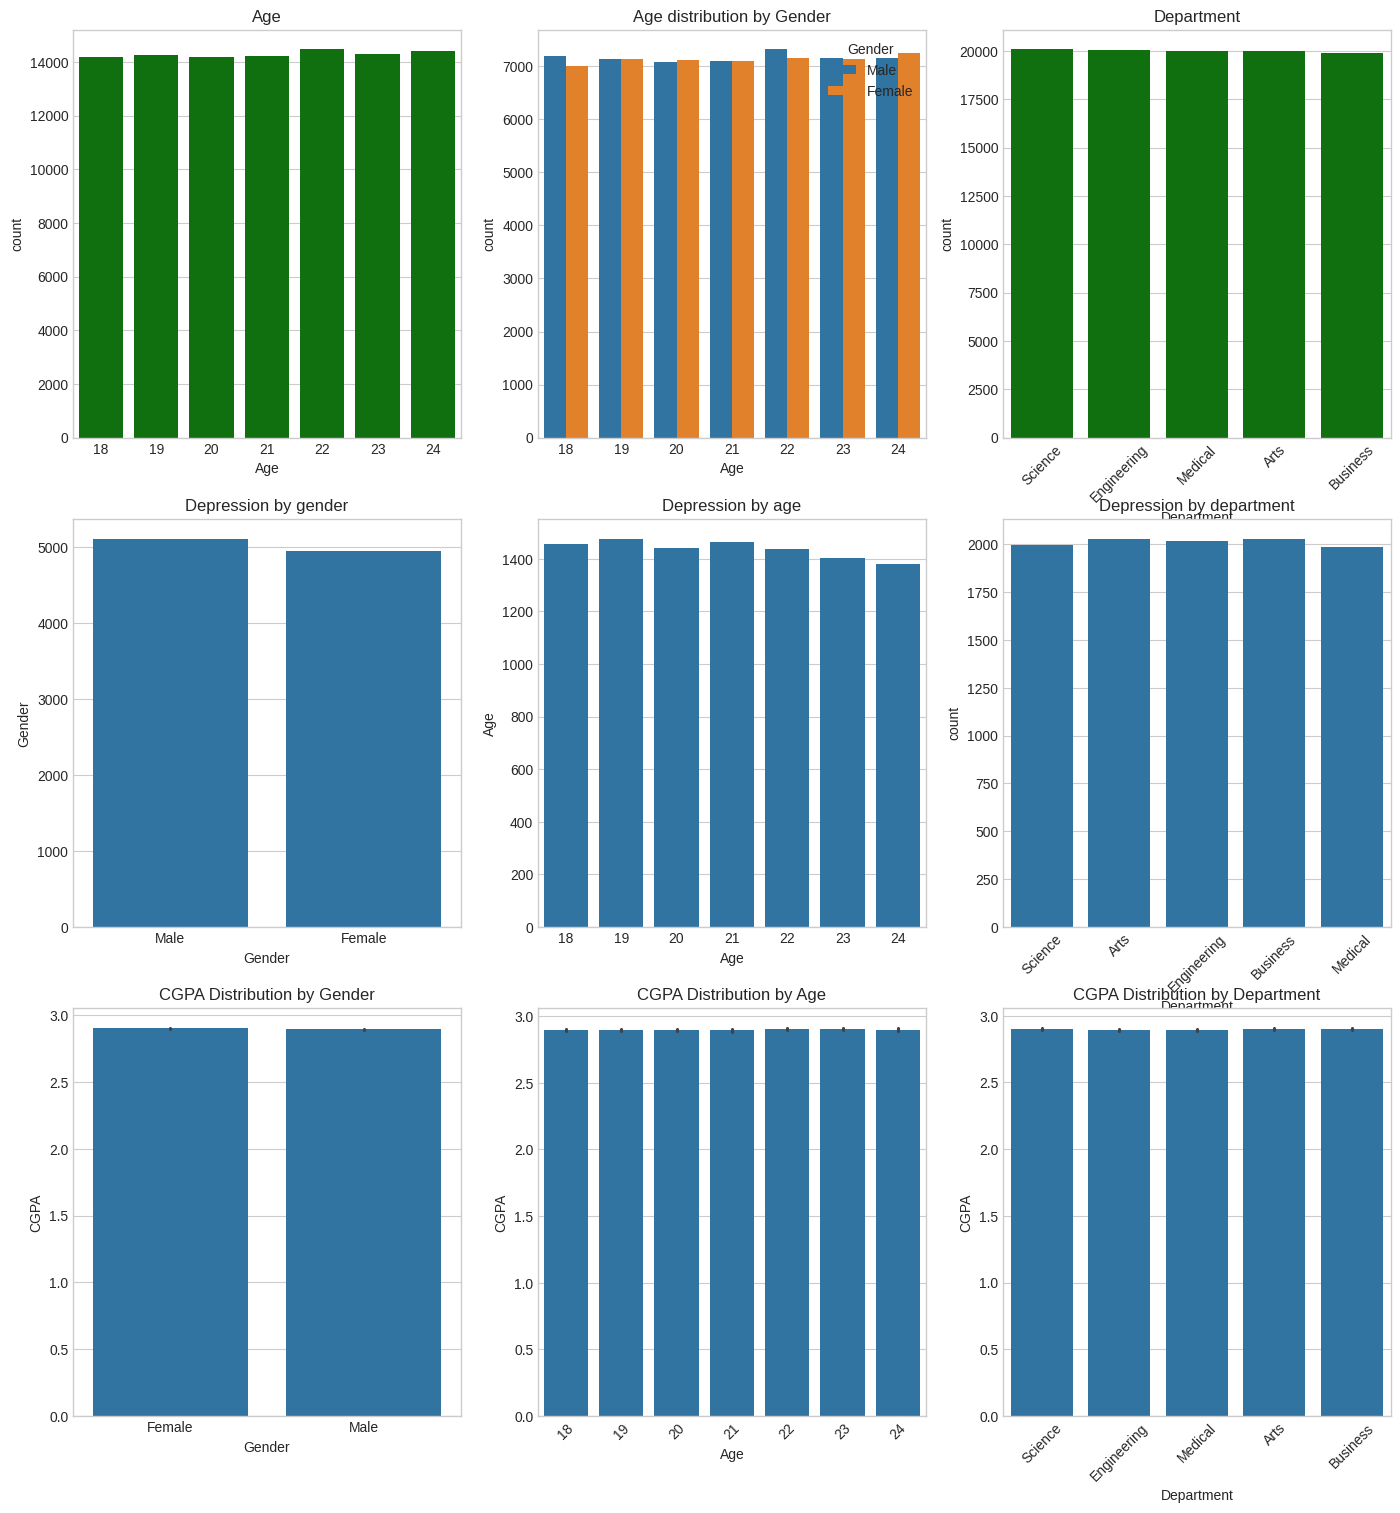

In [336]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 3, figsize=(17, 18))

sns.countplot(data=df, x='Age', color="green", ax=axes[0, 0])
axes[0, 0].set_title('Age')

sns.countplot(data=df, x='Age', hue='Gender', ax=axes[0, 1])
axes[0, 1].set_title('Age distribution by Gender')
axes[0, 1].legend(title='Gender')


df_depression_true = df[df['Depression'] == True]
sns.countplot(data=df_depression_true, x='Gender', ax=axes[1, 0])
axes[1, 0].set_title('Depression by gender')
axes[1, 0].set_ylabel('Gender')

sns.countplot(data=df_depression_true, x='Age', ax=axes[1, 1])
axes[1, 1].set_title('Depression by age')
axes[1, 1].set_ylabel('Age')

sns.countplot(data=df_depression_true, x='Department', ax=axes[1, 2])
axes[1, 2].set_title('Depression by department')
axes[1, 2].tick_params(axis='x', rotation = 45)



sns.countplot(data=df, x='Department', color="green", ax=axes[0, 2])
axes[0, 2].set_title('Department')
axes[0, 2].tick_params(axis='x', rotation = 45)


sns.barplot(data=df, x='Gender', y='CGPA', ax=axes[2, 0])
axes[2, 0].set_title('CGPA Distribution by Gender')
axes[2, 0].set_ylabel('CGPA')

sns.barplot(data=df, x='Age', y='CGPA', ax=axes[2, 1])
axes[2, 1].set_title('CGPA Distribution by Age')
axes[2, 1].set_ylabel('CGPA')
axes[2, 1].tick_params(axis='x', rotation=45)

sns.barplot(data=df, x='Department', y='CGPA', ax=axes[2, 2])
axes[2, 2].set_title('CGPA Distribution by Department')
axes[2, 2].set_ylabel('CGPA')
axes[2, 2].tick_params(axis='x', rotation=45)

Нетрудно заметить, что гендер, департамент и возраст практически не влияют на CGPA и депрессию студентов.

In [337]:
df = df[df['Sleep_Duration'] + df['Study_Hours'] + df['Social_Media_Hours'] <= 24.0 ]

In [338]:
df.describe()

,Student_ID,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,99921.000000,99921.000000,99921.000000,99921.000000,99921.000000,99921.000000,99921.000000,99921.000000
mean,51001.221315,21.008887,2.898246,6.994291,4.505956,3.501174,74.352458,4.131504
std,28868.611597,2.000381,0.532189,1.496934,1.972359,1.485036,43.363229,1.424150
min,1001.000000,18.000000,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000
25%,26000.000000,19.000000,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000
50%,51003.000000,21.000000,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000
75%,76002.000000,23.000000,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000
max,101000.000000,24.000000,4.000000,12.000000,12.800000,10.000000,149.000000,10.000000


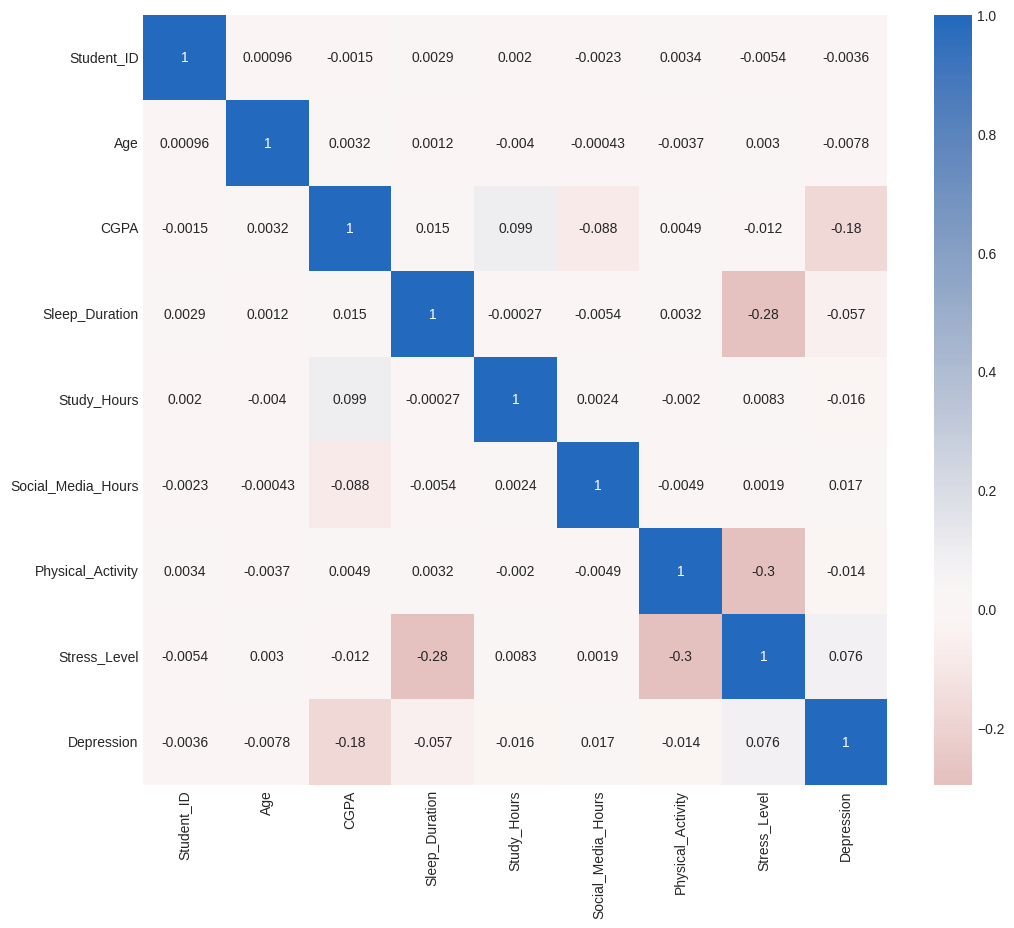

Strong correlations:
           feature_1           feature_2  correlation  strength
4  Physical_Activity        Stress_Level    -0.296496  negative
3     Sleep_Duration        Stress_Level    -0.282099  negative
2               CGPA          Depression    -0.179013  negative
0               CGPA         Study_Hours     0.099485  positive
1               CGPA  Social_Media_Hours    -0.088322  negative
5       Stress_Level          Depression     0.076015  positive


In [339]:
import seaborn as sns
import matplotlib.pyplot as plt


def find_strong_correlations(corr_matrix, threshold=0.07):
    """Найти сильную корреляцию между признаками"""
    strong_pairs = []
    columns = corr_matrix.columns

    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):
            corr_val = corr_matrix.iloc[i, j]

            if pd.notnull(corr_val) and abs(corr_val) >= threshold:
                strong_pairs.append({
                    'feature_1': columns[i],
                    'feature_2': columns[j],
                    'correlation': corr_val,
                    'strength': 'positive' if corr_val > 0 else 'negative'
                })

    if strong_pairs:
        return pd.DataFrame(strong_pairs).sort_values(
            'correlation', key=lambda x: x.abs(), ascending=False
        )
    else:
        return pd.DataFrame()


df_corr = df.corr(numeric_only=True)

strong_cor_df = find_strong_correlations(df_corr)

plt.figure(figsize=(12, 10))
sns.heatmap(df_corr, annot=True, cmap='vlag_r', center=0)
plt.show()

print(f"Strong correlations:\n{strong_cor_df}")

### Основные коррелирующие признаки:

Физическая Активность/Длина Сна -> Уровень Стресса

CGPA -> Время учебы/Время в Медиа

CGPA/Уровень Стресса -> Депрессия


2

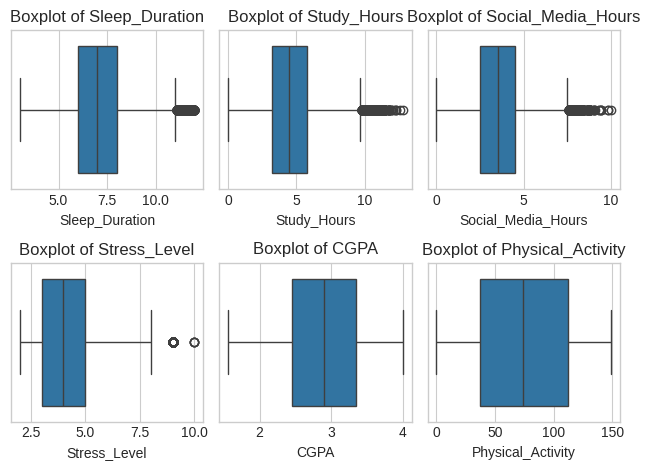

In [340]:
num_features = ['Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Stress_Level', 'CGPA', 'Physical_Activity']

for i, col in enumerate(num_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

Люди, статистика которых попала в выбросы не ведут стандартный образ жизни, а следовательно их образ жизни может стать причиной депрессии, поэтому я не удаляю выбросы.

Так как показатели CGPA и Depression почти не отличаются для учеников разного пола, департмента и возраста, так что данным фактором я решил пренебречь.

In [341]:
df.drop(columns=['Student_ID', 'Age', 'Gender', 'Department'], inplace=True)
df.head()

,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,3.50,7.3,3.3,3.4,114,5,False
1,2.72,5.5,7.2,6.0,142,2,False
2,3.01,5.4,2.3,1.8,137,3,False
3,3.63,8.1,2.0,4.6,130,3,False
4,3.14,6.8,2.6,4.3,4,6,False


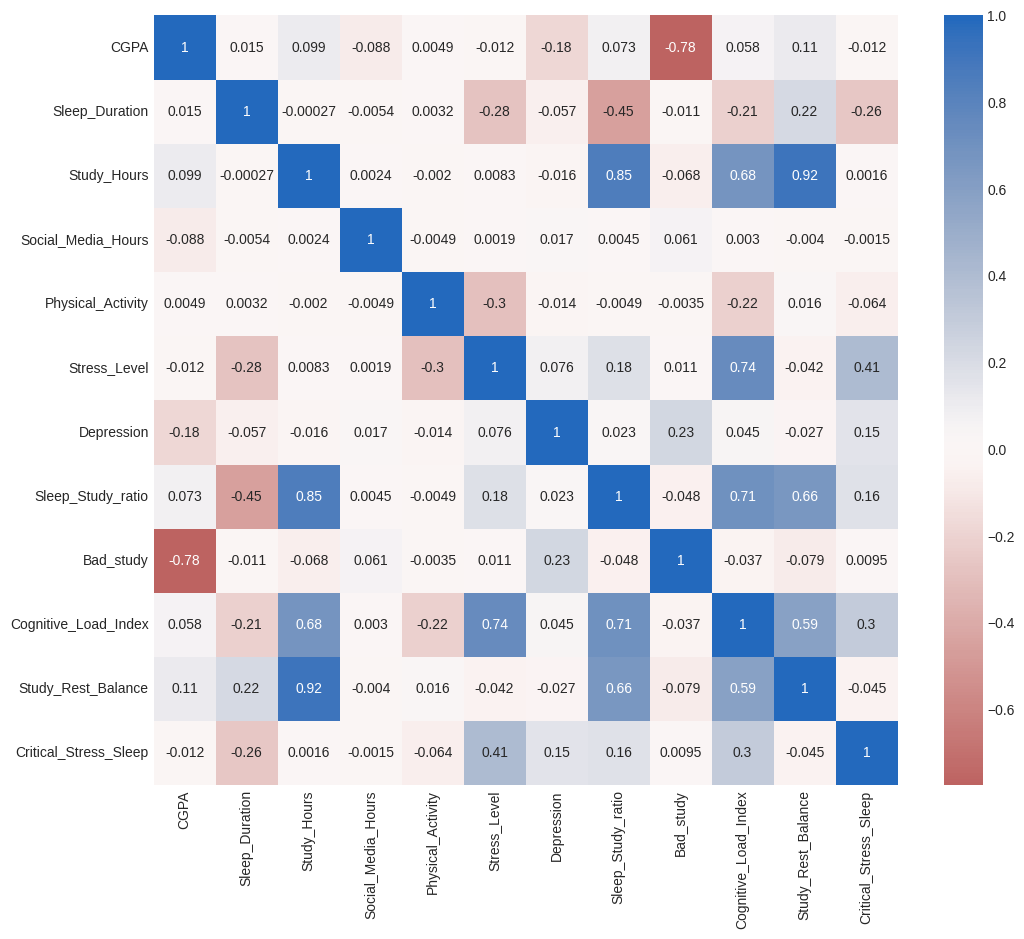

Strong correlations:
               feature_1              feature_2  correlation  strength
13           Study_Hours     Study_Rest_Balance     0.916462  positive
11           Study_Hours      Sleep_Study_ratio     0.850545  positive
4                   CGPA              Bad_study    -0.775061  negative
18          Stress_Level   Cognitive_Load_Index     0.737301  positive
22     Sleep_Study_ratio   Cognitive_Load_Index     0.707022  positive
12           Study_Hours   Cognitive_Load_Index     0.681636  positive
23     Sleep_Study_ratio     Study_Rest_Balance     0.655574  positive
26  Cognitive_Load_Index     Study_Rest_Balance     0.588584  positive
7         Sleep_Duration      Sleep_Study_ratio    -0.454636  negative
19          Stress_Level  Critical_Stress_Sleep     0.410154  positive
27  Cognitive_Load_Index  Critical_Stress_Sleep     0.301186  positive
14     Physical_Activity           Stress_Level    -0.296496  negative
6         Sleep_Duration           Stress_Level    -0.28

In [342]:
def new_features(df):
  df2 = df.copy()

  # Отношение времени учебы к времени сна
  df2['Sleep_Study_ratio'] = (df2['Study_Hours'] / (df2['Sleep_Duration'] + 1e-3)).astype(float)
  # Плохая Успеваемость(средний балл <= 2.5)
  df2['Bad_study'] = (df2['CGPA'] <= 2.5).astype(int)
  # Когнитивная нагрузка
  df2['Cognitive_Load_Index'] = df2['Study_Hours'] * 0.4 + df2['Stress_Level'] * 0.6
  # время учебы к времени отдыха
  df2['Study_Rest_Balance'] = (df2['Study_Hours'] / (24 - df2['Study_Hours'] - df2['Physical_Activity'] / 60 / 7 - df2['Sleep_Duration'] + 1e-3)).astype(float)
  # Критическое время сна и критический уровень стресса
  df2['Critical_Stress_Sleep'] = (df2['Sleep_Duration'] < 6) & (df['Stress_Level'] > 7)

  return df2

new_df = new_features(df)
new_df_corr = new_df.corr(numeric_only=True)

strong_cor_new_df = find_strong_correlations(new_df_corr)

plt.figure(figsize=(12, 10))
sns.heatmap(new_df_corr, annot=True, cmap='vlag_r', center=0)
plt.show()

print(f"Strong correlations:\n{strong_cor_new_df}")


Как видно по матрице признак Bad Study оказался весьма высоко коррелирующим с наличием депрессии. Critical_Stress_Sleep также коррелирует с депрессией.

Также Study_Rest_Balance коррелирует с CGPA

4

In [343]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Для регрессии
X_reg = new_df.drop(columns=['CGPA', 'Bad_study'])
y_reg = new_df['CGPA'].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42, shuffle=True
) # Делим 80/20

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)



📊 Метрики для Train:
  MAE:  0.44
  RMSE: 0.52
  R²:   0.0527
  MAPE: 16.12%

📊 Метрики для Test:
  MAE:  0.44
  RMSE: 0.52
  R²:   0.0507
  MAPE: 16.02%


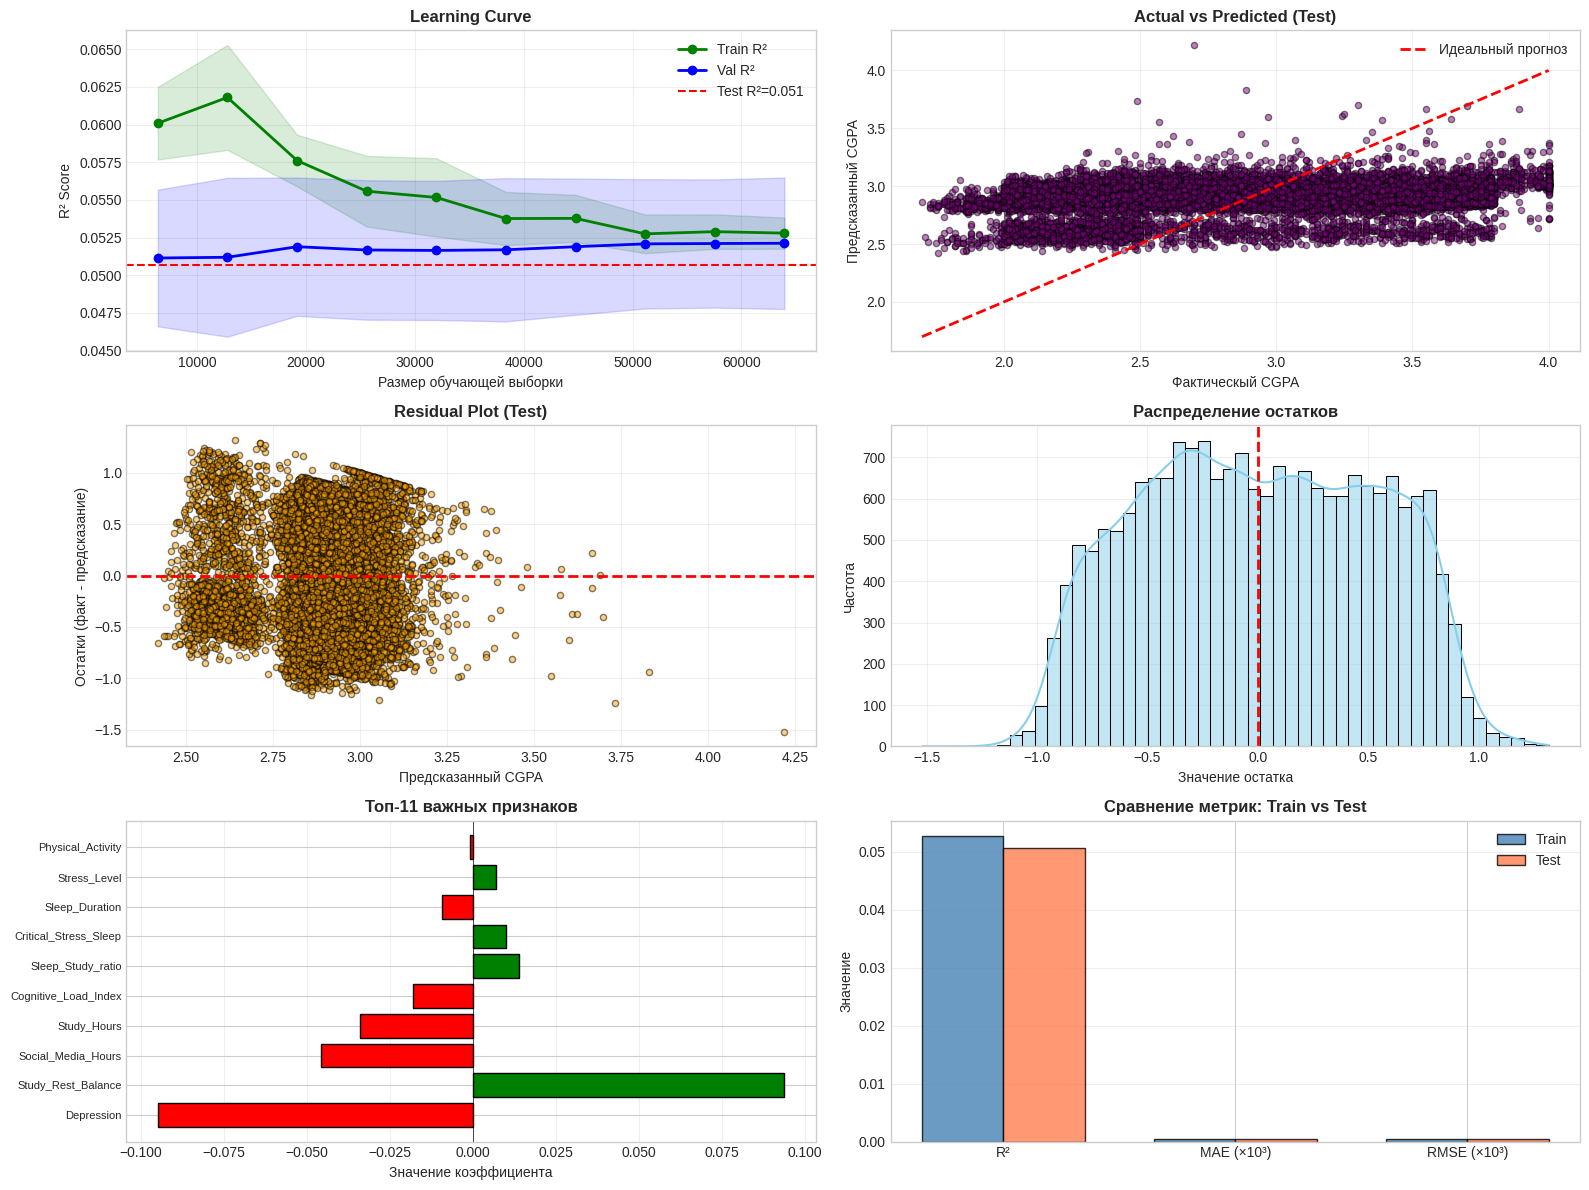

In [344]:
from sklearn.model_selection import learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# Базовые метрики
def evaluate_reg(y_true, y_pred, dataset_name="Dataset"):
    """Расчет и вывод метрик качества"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    print(f"\n📊 Метрики для {dataset_name}:")
    print(f"  MAE:  {mae:,.2f}")
    print(f"  RMSE: {rmse:,.2f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")

    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

train_metrics = evaluate_reg(y_train, y_train_pred, "Train")
test_metrics = evaluate_reg(y_test, y_test_pred, "Test")

plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 12))

ax1 = plt.subplot(3, 2, 1)
train_sizes, train_scores, val_scores = learning_curve(
    model, X_train_scaled, y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='r2',
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

ax1.plot(train_sizes, train_mean, 'o-', color='green', label='Train R²', linewidth=2)
ax1.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='green')
ax1.plot(train_sizes, val_mean, 'o-', color='blue', label='Val R²', linewidth=2)
ax1.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='blue')
ax1.set_xlabel('Размер обучающей выборки', fontsize=10)
ax1.set_ylabel('R² Score', fontsize=10)
ax1.set_title('Learning Curve', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=test_metrics['R2'], color='red', linestyle='--', lw=1.5, label=f'Test R²={test_metrics["R2"]:.3f}')
ax1.legend()

ax2 = plt.subplot(3, 2, 2)
ax2.scatter(y_test, y_test_pred, alpha=0.5, edgecolors='black', s=20, color='purple')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальный прогноз')
ax2.set_xlabel('Фактическый CGPA', fontsize=10)
ax2.set_ylabel('Предсказанный CGPA', fontsize=10)
ax2.set_title('Actual vs Predicted (Test)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3 = plt.subplot(3, 2, 3)
residuals = y_test - y_test_pred
ax3.scatter(y_test_pred, residuals, alpha=0.5, edgecolors='black', s=20, color='orange')
ax3.axhline(y=0, color='red', linestyle='--', lw=2)
ax3.set_xlabel('Предсказанный CGPA', fontsize=10)
ax3.set_ylabel('Остатки (факт - предсказание)', fontsize=10)
ax3.set_title('Residual Plot (Test)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

ax4 = plt.subplot(3, 2, 4)
sns.histplot(residuals, bins=50, kde=True, ax=ax4, color='skyblue', edgecolor='black')
ax4.axvline(x=0, color='red', linestyle='--', lw=2)
ax4.set_xlabel('Значение остатка', fontsize=10)
ax4.set_ylabel('Частота', fontsize=10)
ax4.set_title('Распределение остатков', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

ax5 = plt.subplot(3, 2, 5)
coefficients = pd.DataFrame({
    'feature': X_reg.columns,
    'coef': model.coef_
})
coefficients = coefficients.sort_values(by='coef', key=lambda x: np.abs(x), ascending=False).head(15)

colors = ['green' if c > 0 else 'red' for c in coefficients['coef']]
bars = ax5.barh(coefficients['feature'], coefficients['coef'], color=colors, edgecolor='black')
ax5.set_xlabel('Значение коэффициента', fontsize=10)
ax5.set_title('Топ-11 важных признаков', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='x')
ax5.axvline(x=0, color='black', lw=0.5)
plt.setp(ax5.get_yticklabels(), fontsize=8)

ax6 = plt.subplot(3, 2, 6)
metrics_names = ['R²', 'MAE', 'RMSE']
x_pos = np.arange(len(metrics_names))
width = 0.35

train_vals = [train_metrics['R2'], train_metrics['MAE']/1000, train_metrics['RMSE']/1000]
test_vals = [test_metrics['R2'], test_metrics['MAE']/1000, test_metrics['RMSE']/1000]

ax6.bar(x_pos - width/2, train_vals, width, label='Train', alpha=0.8, edgecolor='black', color='steelblue')
ax6.bar(x_pos + width/2, test_vals, width, label='Test', alpha=0.8, edgecolor='black', color='coral')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(['R²', 'MAE (×10³)', 'RMSE (×10³)'])
ax6.set_ylabel('Значение', fontsize=10)
ax6.set_title('Сравнение метрик: Train vs Test', fontsize=12, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('linear_regression_results.png', dpi=300, bbox_inches='tight')
plt.show()


### Вывод
Как можно заметить, данная модель крайне слабо определяет оценку из-за низкой корреляции признаков. Признак Study_Rest_Balance является наиболее определяющим, но в общем модель работает плохо.

6

In [345]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve, roc_curve


In [346]:
class LogisticRegressionCustom:
    """
    Логистическая регрессия с градиентным спуском.
    Функция активации: Сигмоида
    Функция потерь: Binary Cross-Entropy (Log Loss)
    """
    def __init__(self, learning_rate=0.01, n_iterations=100, random_state=42, penalty='l2', alpha=0.01):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.random_state = random_state
        self.penalty = penalty
        self.alpha = alpha
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _initialize_parameters(self, n_features):
        """Инициализация весов и смещения"""
        np.random.seed(self.random_state)
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0.0

    def _sigmoid(self, z):
        """Сигмоидная функция активации"""
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def _compute_loss(self, y_true, y_pred_proba):
        """Вычисление Binary Cross-Entropy Loss"""
        epsilon = 1e-15
        y_pred_proba = np.clip(y_pred_proba, epsilon, 1 - epsilon)

        loss = -np.mean(y_true * np.log(y_pred_proba) + (1 - y_true) * np.log(1 - y_pred_proba))

        if self.penalty == 'l2':
            loss += (self.alpha / (2 * len(y_true))) * np.sum(self.weights ** 2)

        return loss

    def fit(self, X, y):
        """Обучение модели градиентным спуском"""
        n_samples, n_features = X.shape
        self._initialize_parameters(n_features)
        self.loss_history = []
        self.val_accuracy = []
        self.val_loss = []
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=0.20, random_state=42, shuffle=True
        )

        for epoch in range(self.n_iterations):
            linear_output = np.dot(X_train, self.weights) + self.bias
            y_pred = self._sigmoid(linear_output)

            loss = self._compute_loss(y_train, y_pred)
            self.loss_history.append(loss)

            error = y_pred - y_train
            dw = (1 / n_samples) * np.dot(X_train.T, error)
            db = (1 / n_samples) * np.sum(error)
            if self.penalty == 'l2':
                dw += (self.alpha / n_samples) * self.weights

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            val_predictions = self.predict(X_val)
            val_accuracy = accuracy_score(y_val, val_predictions)
            self.val_accuracy.append(val_accuracy)
            val_proba = self.predict_proba(X_val)
            val_loss = self._compute_loss(y_val, val_proba)
            self.val_loss.append(val_loss)

            if epoch % 100 == 99 or epoch == 0:
                print(f"Epoch {epoch+1}/{self.n_iterations}: "f"Train Loss = {loss:.6f}, "f"Val Accuracy = {val_accuracy:.4f}, "f"Val Loss = {val_loss:.6f}")

        return self

    def predict_proba(self, X):
        """Вероятность принадлежности к классу 1"""
        if self.weights is None or self.bias is None:
          raise RuntimeError("Модель не обучена. Сначала вызовите model.fit(X, y)")

        linear_output = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_output)

    def predict(self, X, threshold=0.191):
        """Предсказание класса (0 или 1)"""
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)

    def score(self, X, y):
        """Точность модели"""
        predictions = self.predict(X)
        return accuracy_score(y, predictions)


In [347]:
y = new_df['Depression']
X = new_df.drop(columns='Depression')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)
# Разделил в отношении 80:20

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

epochs = 500
step = 0.05

model = LogisticRegressionCustom(
    learning_rate=step,
    n_iterations=epochs,
    random_state=42,
    penalty='l2',
    alpha=0.01
)


model.fit(X_train_scaled, y_train)

proba = model.predict_proba(X_test_scaled)
y_test_proba = proba[:, 1] if proba.ndim == 2 else proba

precisions, recalls, thresholds = precision_recall_curve(y_test, y_test_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Оптимальный порог: {best_threshold:.3f}")
print(f"F1 при этом пороге: {f1_scores[best_idx]:.4f}")

y_test_pred_opt = (y_test_proba >= best_threshold).astype(int)
y_train_pred_opt = (model.predict_proba(X_train_scaled) >= best_threshold).astype(int)

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)
y_test_proba = model.predict_proba(X_test_scaled)

def evaluate_classification(y_true, y_pred, y_proba=None, dataset_name="Dataset"):
    """Расчет и вывод метрик классификации"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc_roc = roc_auc_score(y_true, y_proba) if y_proba is not None else None

    print(f"\n📊 Метрики для {dataset_name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    if auc_roc:
        print(f"  AUC-ROC:   {auc_roc:.4f}")

    return {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1': f1, 'AUC-ROC': auc_roc}

# train_metrics = evaluate_classification(y_train, y_train_pred, dataset_name="Train")
# test_metrics = evaluate_classification(y_test, y_test_pred, y_proba=y_test_proba, dataset_name="Test")

test_metrics = evaluate_classification(y_test, y_test_pred_opt, y_proba=y_test_proba, dataset_name="Test ")
train_metrics = evaluate_classification(y_train, y_train_pred_opt, dataset_name="Train")

Epoch 1/500: Train Loss = 0.693149, Val Accuracy = 0.1059, Val Loss = 0.686578
Epoch 100/500: Train Loss = 0.396337, Val Accuracy = 0.1068, Val Loss = 0.397148
Epoch 200/500: Train Loss = 0.335122, Val Accuracy = 0.7342, Val Loss = 0.337642
Epoch 300/500: Train Loss = 0.315632, Val Accuracy = 0.7354, Val Loss = 0.318714
Epoch 400/500: Train Loss = 0.307705, Val Accuracy = 0.7371, Val Loss = 0.310988
Epoch 500/500: Train Loss = 0.303986, Val Accuracy = 0.7459, Val Loss = 0.307333
Оптимальный порог: 0.191
F1 при этом пороге: 0.3119

📊 Метрики для Test :
  Accuracy:  0.7474
  Precision: 0.2090
  Recall:    0.6144
  F1-Score:  0.3119
  AUC-ROC:   0.7055

📊 Метрики для Train:
  Accuracy:  0.7426
  Precision: 0.2235
  Recall:    0.6105
  F1-Score:  0.3272


На данном этапе модель не воспринимала изменение шага или количества эпох, поэтому я изменил порог.

С такими входными данными(шаг, кол-во эпох) модель показала самые приемлимые результаты.

Стоить подметить, что метрики для двух выборок практически идентичны, значит модель не переобучена.

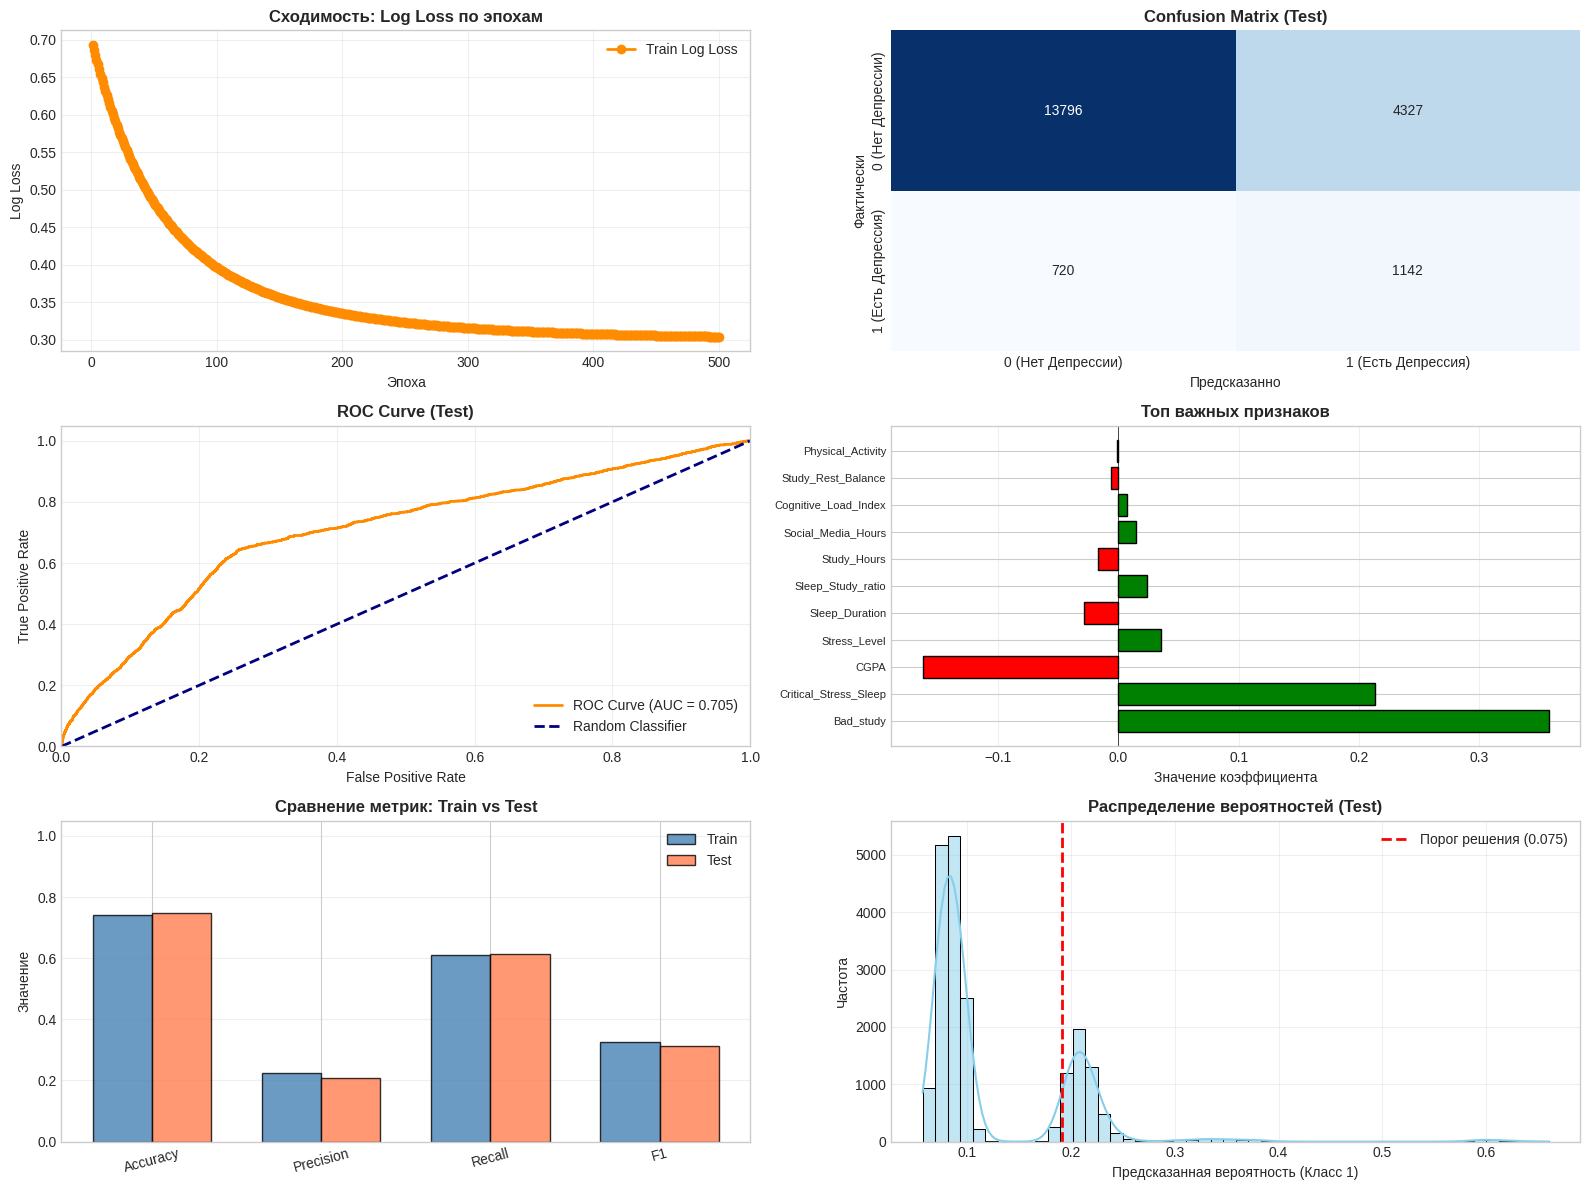

In [348]:
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 12))

ax1 = plt.subplot(3, 2, 1)
ax1.plot(range(1, epochs + 1), model.loss_history, 'o-', color='darkorange', linewidth=2, label='Train Log Loss')
ax1.set_xlabel('Эпоха', fontsize=10)
ax1.set_ylabel('Log Loss', fontsize=10)
ax1.set_title('Сходимость: Log Loss по эпохам', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

ax2 = plt.subplot(3, 2, 2)
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2, cbar=False)
ax2.set_xlabel('Предсказанно', fontsize=10)
ax2.set_ylabel('Фактически', fontsize=10)
ax2.set_title('Confusion Matrix (Test)', fontsize=12, fontweight='bold')
ax2.set_xticklabels(['0 (Нет Депрессии)', '1 (Есть Депрессия)'])
ax2.set_yticklabels(['0 (Нет Депрессии)', '1 (Есть Депрессия)'])

ax3 = plt.subplot(3, 2, 3)
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
ax3.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {test_metrics["AUC-ROC"]:.3f})')
ax3.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel('False Positive Rate', fontsize=10)
ax3.set_ylabel('True Positive Rate', fontsize=10)
ax3.set_title('ROC Curve (Test)', fontsize=12, fontweight='bold')
ax3.legend(loc="lower right")
ax3.grid(True, alpha=0.3)

ax4 = plt.subplot(3, 2, 4)
weights_df = pd.DataFrame({
    'feature': X.columns,
    'weight': model.weights
})
weights_df = weights_df.sort_values(by='weight', key=lambda x: np.abs(x), ascending=False).head(15)

colors = ['green' if w > 0 else 'red' for w in weights_df['weight']]
bars = ax4.barh(weights_df['feature'], weights_df['weight'], color=colors, edgecolor='black')
ax4.set_xlabel('Значение коэффициента', fontsize=10)
ax4.set_title('Топ важных признаков', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')
ax4.axvline(x=0, color='black', lw=0.5)
plt.setp(ax4.get_yticklabels(), fontsize=8)

ax5 = plt.subplot(3, 2, 5)
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1']
x_pos = np.arange(len(metrics_names))
width = 0.35

train_vals = [train_metrics['Accuracy'], train_metrics['Precision'], train_metrics['Recall'], train_metrics['F1']]
test_vals = [test_metrics['Accuracy'], test_metrics['Precision'], test_metrics['Recall'], test_metrics['F1']]

ax5.bar(x_pos - width/2, train_vals, width, label='Train', alpha=0.8, edgecolor='black', color='steelblue')
ax5.bar(x_pos + width/2, test_vals, width, label='Test', alpha=0.8, edgecolor='black', color='coral')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(metrics_names, rotation=15)
ax5.set_ylabel('Значение', fontsize=10)
ax5.set_title('Сравнение метрик: Train vs Test', fontsize=12, fontweight='bold')
ax5.set_ylim(0, 1.05)
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

ax6 = plt.subplot(3, 2, 6)
sns.histplot(y_test_proba, bins=50, kde=True, ax=ax6, color='skyblue', edgecolor='black')
ax6.axvline(x=0.191, color='red', linestyle='--', lw=2, label='Порог решения (0.075)')
ax6.set_xlabel('Предсказанная вероятность (Класс 1)', fontsize=10)
ax6.set_ylabel('Частота', fontsize=10)
ax6.set_title('Распределение вероятностей (Test)', fontsize=12, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('logistic_regression_results.png', dpi=300, bbox_inches='tight')
plt.show()

Видно, что признак Bad Study помогает модели исключить большую часть студентов, однако

In [349]:
print(f"  Initial Loss: {model.loss_history[0]:.4f}")
print(f"  Final Loss: {model.loss_history[-1]:.4f}")
loss_reduction = (model.loss_history[0] - model.loss_history[-1]) / model.loss_history[0] * 100
print(f"\n Loss снизился на {loss_reduction:.1f}%")

  Initial Loss: 0.6931
  Final Loss: 0.3040

 Loss снизился на 56.1%


## Вывод
Предсказывать CGPA и Депрессию крайне трудно из-за большого количества факторов, которые для каждого студента крайне индивидуальны, а следовательно модель в большинстве случаев будет ошибаться, но в отличие от первой модели она гораздо лучше предсказывает наличие депрессии.